# RF: Pillar Features with NFL-Way Scouting Language

Recreates the position-stratified RF notebook using the NFL-Way pillar scoring pipeline. Each prospect is scored against four archetype pillars, then the pillar scores, rating, and position are fed into a random forest to predict `made_it_contract`. Global and stratified models mirror the original structure.

This notebook loads `data/processed/draft_enriched_with_contracts.csv`, applies the NFL-Way preprocessing described in the nfl_way_pillar_scoring notebook, and builds RF models using the derived pillar features plus structured inputs.

In [2]:

import re
import warnings
from itertools import chain

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures
from nltk import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sffra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sffra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sffra\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sffra\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Controls & Constants

In [4]:

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
DATA_PATH = 'data/processed/draft_enriched_with_contracts.csv'
YEAR_MIN = 2014
YEAR_MAX = 2021
GRADE_MAX = 8.5
TARGET = 'made_it_contract'
STRAT_LEVEL = 'Pos_Group'
MIN_GROUP_N = 50
PILLAR_COLS = [
    'score_athletic',
    'score_technical',
    'score_character',
    'score_iq',
]
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)


## Phase 1: NFL-Way Strengths Preprocessing

In [5]:

df = pd.read_csv('../data/processed/draft_enriched_with_contracts.csv')
df = df[(df['year'] >= YEAR_MIN) & (df['year'] <= YEAR_MAX)].copy()
df = df[df['grade'] <= GRADE_MAX].copy()
df = df.dropna(subset=[TARGET, 'grade', 'Pos_Group', 'position']).copy()
df[TARGET] = df[TARGET].astype(int)
df['rating'] = df['grade']
df = df.reset_index(drop=True)

for col in ['strengths']:
    df[col] = df[col].fillna('').astype(str)

def replace_hyphen(text: str) -> str:
    return re.sub(r'[-–—]', ' ', text)

df['strengths_normalized'] = df['strengths'].apply(replace_hyphen)

curated_phrases = [
    'pad level', 'change of direction', 'press coverage', 'ball skills', 'hand placement',
    'play recognition', 'run blocking', 'anchor strength', 'coverage awareness', 'stack and shed',
    'man coverage', 'zone coverage', 'offensive line', 'route depth', 'field vision',
    'lower body', 'upper body', 'catch radius', 'short area burst', 'long speed',
    'process speed', 'third down', 'chain mover', 'mental processing', 'football iq'
]
curated_map = {phrase: phrase.replace(' ', '_') for phrase in curated_phrases}

def stitch_curated(text: str) -> str:
    text = text.lower()
    for phrase, replacement in curated_map.items():
        text = re.sub(rf'\b{re.escape(phrase)}\b', replacement, text)
    return text

df['strengths_curated'] = df['strengths_normalized'].apply(stitch_curated)

all_tokens = list(chain.from_iterable(word_tokenize(doc) for doc in df['strengths_curated']))
finder = BigramCollocationFinder.from_words(all_tokens)
finder.apply_freq_filter(2)
measures = BigramAssocMeasures()
top_bigrams = finder.nbest(measures.pmi, 30)
bigram_map = {' '.join(bigram): '_'.join(bigram) for bigram in top_bigrams}

def stitch_bigrams(text: str) -> str:
    for phrase, replacement in bigram_map.items():
        text = re.sub(rf'\b{re.escape(phrase)}\b', replacement, text)
    return text

df['strengths_bigrams'] = df['strengths_curated'].apply(stitch_bigrams)

domain_fillers = {'prospect', 'player', 'shows', 'ability', 'potential'}
stop_words = set(stopwords.words('english'))
preserve_directionals = {'high', 'low', 'deep', 'heavy'}
stop_words -= preserve_directionals
stop_words |= domain_fillers
lemmatizer = WordNetLemmatizer()

def is_alpha_like(token: str) -> bool:
    return token.replace('_', '').isalpha()

def tokenize_and_lemmatize(text: str):
    tokens = []
    for token in word_tokenize(text):
        token_lower = token.lower()
        if token_lower in stop_words or not is_alpha_like(token_lower):
            continue
        lemma = lemmatizer.lemmatize(token_lower.replace('_', ' '))
        tokens.append(lemma.replace(' ', '_'))
    return tokens

df['tokens'] = df['strengths_bigrams'].apply(tokenize_and_lemmatize)
df['clean_strengths'] = df['tokens'].apply(' '.join)

print(f'Rows after filtering: {len(df)}')
print(f'Positive rate: {df[TARGET].mean():.1%}')


Rows after filtering: 3372
Positive rate: 30.8%


In [6]:

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['clean_strengths'])
archetypes = {
    'athletic': 'Elite physical athleticism, speed, explosiveness, and body control.',
    'technical': 'Refined technical mechanics, hand usage, footwork, and positional skill.',
    'character': 'High motor, competitive toughness, leadership, and relentless effort.',
    'iq': 'High football IQ, play recognition, mental processing, and anticipation.',
}
archetype_order = list(archetypes.keys())
archetype_texts = [archetypes[key] for key in archetype_order]
archetype_matrix = vectorizer.transform(archetype_texts)
similarity_matrix = cosine_similarity(tfidf_matrix, archetype_matrix)
similarity_df = pd.DataFrame(similarity_matrix, columns=archetype_order, index=df.index)

score_df = similarity_df.copy()
for column in score_df.columns:
    min_val = similarity_df[column].min()
    max_val = similarity_df[column].max()
    if max_val > min_val:
        score_df[column] = 100 * (similarity_df[column] - min_val) / (max_val - min_val)
    else:
        score_df[column] = 100 * similarity_df[column]

rename_map = {
    'athletic': 'score_athletic',
    'technical': 'score_technical',
    'character': 'score_character',
    'iq': 'score_iq',
}
score_df = score_df.rename(columns=rename_map)
df = pd.concat([df, score_df], axis=1)

display_columns = ['player_name'] + PILLAR_COLS
display_df = df[display_columns].sort_values('score_athletic', ascending=False)
print('Sample pillar scores:')
print(display_df.head().to_string(index=False))

for pillar in PILLAR_COLS:
    top5 = df[['player_name', pillar]].sort_values(pillar, ascending=False).head(5)
    print(f"\nTop 5 players for {pillar}: {pillar.replace('score_', '').title()} pillar")
    print(top5.to_string(index=False))


Sample pillar scores:
            player_name  score_athletic  score_technical  score_character  score_iq
        Phillip Dorsett      100.000000         0.000000          0.00000  6.197117
Jeremiah Owusu-Koramoah       91.584515         0.000000         24.65378 21.812912
            Tarik Black       89.411114         0.000000          0.00000  0.000000
           Alim McNeill       87.327524         3.950244          0.00000  3.384624
     Oluwole Betiku Jr.       86.309527         7.559933          0.00000  0.000000

Top 5 players for score_athletic: Athletic pillar
            player_name  score_athletic
        Phillip Dorsett      100.000000
Jeremiah Owusu-Koramoah       91.584515
            Tarik Black       89.411114
           Alim McNeill       87.327524
     Oluwole Betiku Jr.       86.309527

Top 5 players for score_technical: Technical pillar
          player_name  score_technical
        Josh Metellus       100.000000
            Sam Cosmi        90.065639
          Sea

## Phase 2: Pillar-Driven Random Forest Modeling

In [7]:

numeric_cols = PILLAR_COLS + ['rating']
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer([
    ('numeric', 'passthrough', numeric_cols),
    ('pos', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['Pos_Group']),
], remainder='drop')

pipe_global = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(**RF_PARAMS))
])

X = df[numeric_cols + ['Pos_Group']].copy()
y = df[TARGET].values

print('Training global RF (pillar scores + rating + pos one-hot) with 5-fold OOF...')
global_oof = cross_val_predict(
    pipe_global, X, y,
    cv=cv5, method='predict_proba', verbose=1, n_jobs=-1
)[:, 1]

global_pr_auc = average_precision_score(y, global_oof)
baseline = y.mean()
print(f'Global PR-AUC = {global_pr_auc:.4f}')
print(f'Random baseline (positive rate) = {baseline:.4f}')


Training global RF (pillar scores + rating + pos one-hot) with 5-fold OOF...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.


Global PR-AUC = 0.5248
Random baseline (positive rate) = 0.3081


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.2s remaining:    7.9s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.3s finished


## Position-Stratified RF

In [8]:

def make_strat_pipe():
    return Pipeline([
        ('pre', ColumnTransformer([
            ('numeric', 'passthrough', numeric_cols),
        ], remainder='drop')),
        ('clf', RandomForestClassifier(**RF_PARAMS))
    ])

strat_oof = np.full(len(df), np.nan)
strat_results = []

for group in sorted(df[STRAT_LEVEL].dropna().unique()):
    mask = df[STRAT_LEVEL] == group
    grp_df = df[mask].copy()
    n = len(grp_df)
    n_pos = grp_df[TARGET].sum()
    pos_rate = n_pos / n

    if n < MIN_GROUP_N:
        print(f'SKIP {group:<12s} (n={n} < MIN_GROUP_N={MIN_GROUP_N})')
        continue

    n_folds = 5 if n >= 150 else 3
    if n_pos < n_folds:
        print(f'SKIP {group:<12s} (n_pos={n_pos} < n_folds={n_folds})')
        continue

    X_grp = grp_df[numeric_cols].copy()
    y_grp = grp_df[TARGET].values
    cv_grp = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    oof = cross_val_predict(
        make_strat_pipe(), X_grp, y_grp,
        cv=cv_grp, method='predict_proba', n_jobs=-1
    )[:, 1]

    strat_oof[mask] = oof
    pr_auc = average_precision_score(y_grp, oof)
    strat_results.append({
        'stratum': group,
        'n': n,
        'n_pos': int(n_pos),
        'pos_rate': pos_rate,
        'pr_auc': pr_auc,
        'baseline': pos_rate,
        'n_folds': n_folds,
    })
    print(f'{group:<12s}  n={n:>4d}  pos_rate={pos_rate:.1%}  PR-AUC={pr_auc:.4f} ({n_folds}-fold)')

strat_df = pd.DataFrame(strat_results).sort_values('pr_auc', ascending=False)
valid_mask = ~np.isnan(strat_oof)
strat_pr_auc = average_precision_score(y[valid_mask], strat_oof[valid_mask])
print(f'\nStratified overall PR-AUC = {strat_pr_auc:.4f}  (n={int(valid_mask.sum())} / {len(df)})')


DB            n= 631  pos_rate=30.7%  PR-AUC=0.4241 (5-fold)
DT            n= 276  pos_rate=32.6%  PR-AUC=0.5313 (5-fold)
EDGE          n= 431  pos_rate=33.6%  PR-AUC=0.5560 (5-fold)
LB            n= 251  pos_rate=33.5%  PR-AUC=0.4870 (5-fold)
OL            n= 565  pos_rate=35.2%  PR-AUC=0.5651 (5-fold)
QB            n= 147  pos_rate=30.6%  PR-AUC=0.6896 (3-fold)
RB            n= 317  pos_rate=26.2%  PR-AUC=0.4654 (5-fold)
SPECIAL       n=  83  pos_rate=36.1%  PR-AUC=0.4616 (3-fold)
TE            n= 189  pos_rate=31.2%  PR-AUC=0.5248 (5-fold)
WR            n= 482  pos_rate=22.8%  PR-AUC=0.4085 (5-fold)

Stratified overall PR-AUC = 0.5117  (n=3372 / 3372)


In [9]:

print('Summary:')
print('-' * 55)
print(f'Global RF (pillar scores + rating + pos) PR-AUC = {global_pr_auc:.4f}')
print(f'Stratified RF (per {STRAT_LEVEL}) PR-AUC = {strat_pr_auc:.4f}')
print(f'Random baseline (positive rate) = {baseline:.4f}')

summary_df = strat_df[['stratum', 'n', 'n_pos', 'pos_rate', 'pr_auc', 'baseline']].copy()
summary_df['pos_rate'] = summary_df['pos_rate'].map('{:.1%}'.format)
summary_df['baseline'] = summary_df['baseline'].map('{:.3f}'.format)
summary_df['pr_auc'] = summary_df['pr_auc'].map('{:.4f}'.format)
summary_df['lift'] = (
    strat_df['pr_auc'] - strat_df['baseline']
).map('{:+.4f}'.format)
print('\nPer-stratum results:')
print(summary_df.to_string(index=False))


Summary:
-------------------------------------------------------
Global RF (pillar scores + rating + pos) PR-AUC = 0.5248
Stratified RF (per Pos_Group) PR-AUC = 0.5117
Random baseline (positive rate) = 0.3081

Per-stratum results:
stratum   n  n_pos pos_rate pr_auc baseline    lift
     QB 147     45    30.6% 0.6896    0.306 +0.3835
     OL 565    199    35.2% 0.5651    0.352 +0.2129
   EDGE 431    145    33.6% 0.5560    0.336 +0.2196
     DT 276     90    32.6% 0.5313    0.326 +0.2052
     TE 189     59    31.2% 0.5248    0.312 +0.2126
     LB 251     84    33.5% 0.4870    0.335 +0.1524
     RB 317     83    26.2% 0.4654    0.262 +0.2035
SPECIAL  83     30    36.1% 0.4616    0.361 +0.1001
     DB 631    194    30.7% 0.4241    0.307 +0.1166
     WR 482    110    22.8% 0.4085    0.228 +0.1803


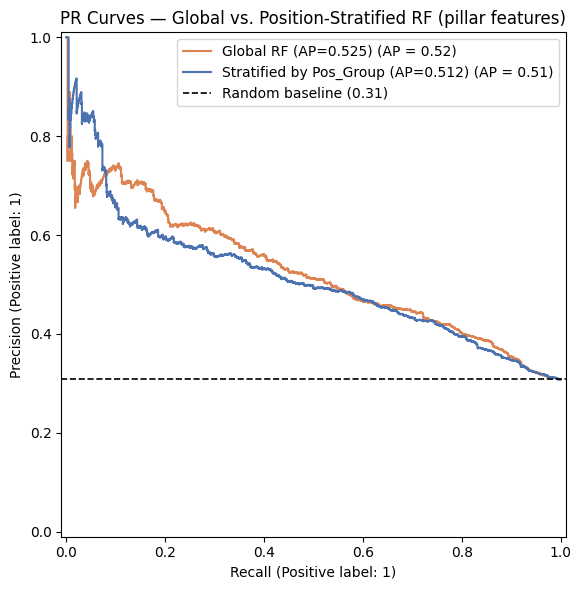

In [10]:

fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y, global_oof, ax=ax,
    name=f'Global RF (AP={global_pr_auc:.3f})',
    color='#DD8452'
)
PrecisionRecallDisplay.from_predictions(
    y[valid_mask], strat_oof[valid_mask], ax=ax,
    name=f'Stratified by {STRAT_LEVEL} (AP={strat_pr_auc:.3f})',
    color='#4C72B0'
)
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1.2,
           label=f'Random baseline ({baseline:.2f})')
ax.set_title('PR Curves — Global vs. Position-Stratified RF (pillar features)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [11]:
# Compare RF without pillar scores vs RF with pillar features
baseline_pipe = Pipeline([
    ('pre', ColumnTransformer([
        ('numeric', 'passthrough', ['rating']),
        ('pos', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['Pos_Group']),
    ], remainder='drop')),
    ('clf', RandomForestClassifier(**RF_PARAMS)),
])

baseline_oof = cross_val_predict(
    baseline_pipe, df[['rating', 'Pos_Group']], y,
    cv=cv5, method='predict_proba', n_jobs=-1
)[:, 1]
baseline_pr_auc = average_precision_score(y, baseline_oof)
print(f'Baseline RF (rating + pos) PR-AUC = {baseline_pr_auc:.4f}')
print(f'Global RF (pillar scores + rating + pos) PR-AUC = {global_pr_auc:.4f}')
print(f'Lift from pillar scores = {global_pr_auc - baseline_pr_auc:+.4f}')

Baseline RF (rating + pos) PR-AUC = 0.5367
Global RF (pillar scores + rating + pos) PR-AUC = 0.5248
Lift from pillar scores = -0.0119


In [ ]:
bin_count = 5
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, pillar in zip(axes.flatten(), PILLAR_COLS):
    agg = (
        df.assign(_bin=lambda d: pd.cut(d[pillar], bins=bin_count, include_lowest=True))
          .groupby('_bin')[TARGET]
          .agg(pos_rate='mean', count='size')
          .reset_index()
    )
    ax.bar(range(len(agg)), agg['count'], alpha=0.4, label='Bin count')
    ax.set_xticks(range(len(agg)))
    labels = [f"{interval.left:.1f}-{interval.right:.1f}" if hasattr(interval, 'left') else str(interval) for interval in agg['_bin']]
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(f"{pillar.replace('score_', '').title()} distribution")
    ax.set_ylabel('Count')
    ax2 = ax.twinx()
    ax2.plot(range(len(agg)), agg['pos_rate'], marker='o', color='C1', label='Made-it rate')
    ax2.set_ylabel('Made-it rate')
    ax2.set_ylim(0, 1)
    ax2.grid(False)
    if ax == axes.flatten()[0]:
        ax2.legend(loc='upper left')
plt.tight_layout()


In [ ]:
pipe_full = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(**RF_PARAMS)),
])
pipe_full.fit(X, y)
feature_names = pipe_full.named_steps['pre'].get_feature_names_out()
importances = pipe_full.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
top_imp = imp_df.nlargest(15, 'importance').copy()
print('Top RF features (full-data fit):')
print(top_imp.to_string(index=False))


In [ ]:
strat_lift = strat_df.copy()
strat_lift['lift'] = strat_lift['pr_auc'] - strat_lift['baseline']
print('Top position groups where text adds signal:')
print(strat_lift.nlargest(5, 'lift')[['stratum', 'n', 'pr_auc', 'baseline', 'lift']].to_string(index=False))
print('
Bottom groups (text may hurt):')
print(strat_lift.nsmallest(5, 'lift')[['stratum', 'n', 'pr_auc', 'baseline', 'lift']].to_string(index=False))


In [ ]:
pillar_only_cols = ['rating'] + PILLAR_COLS
pillar_only_pipe = Pipeline([
    ('pre', ColumnTransformer([
        ('numeric', 'passthrough', pillar_only_cols),
    ], remainder='drop')),
    ('clf', RandomForestClassifier(**RF_PARAMS))
])
pillar_only_oof = cross_val_predict(
    pillar_only_pipe, df[pillar_only_cols], y,
    cv=cv5, method='predict_proba', n_jobs=-1
)[:, 1]
pillar_only_pr_auc = average_precision_score(y, pillar_only_oof)
text_preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(ngram_range=(1, 2), min_df=0.01, max_df=0.6), 'clean_strengths'),
    ('numeric', 'passthrough', ['rating']),
    ('pos', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['Pos_Group']),
], remainder='drop')
text_pipe = Pipeline([
    ('pre', text_preprocessor),
    ('clf', RandomForestClassifier(**RF_PARAMS))
])
text_oof = cross_val_predict(
    text_pipe, df[['clean_strengths', 'rating', 'Pos_Group']], y,
    cv=cv5, method='predict_proba', n_jobs=-1
)[:, 1]
text_pr_auc = average_precision_score(y, text_oof)
print(f'Pillar-only RF (no pos) PR-AUC        = {pillar_only_pr_auc:.4f}')
print(f'TF-IDF RF (rating + pos + text) PR-AUC = {text_pr_auc:.4f}')


In [ ]:
log_pre = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_cols),
    ('pos', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['Pos_Group']),
], remainder='drop')
log_pipe = Pipeline([
    ('pre', log_pre),
    ('clf', LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE)),
])
log_oof = cross_val_predict(
    log_pipe, X, y,
    cv=cv5, method='predict_proba', n_jobs=-1
)[:, 1]
log_pr_auc = average_precision_score(y, log_oof)
print(f'Logistic regression (pillar + rating + pos) PR-AUC = {log_pr_auc:.4f}')
log_pipe.fit(X, y)
PartialDependenceDisplay.from_estimator(
    log_pipe, X, features=numeric_cols,
    kind='average', grid_resolution=20
)
plt.tight_layout()
plt.show()
